# Python Essencial

Base de Python para acompanhar o curso inteiro. Os tópicos aqui foram escolhidos olhando
para trás — são exatamente os recursos de Python que os módulos 01 a 10 usam o tempo
todo: variáveis e tipos, estruturas de controle, funções, `numpy`, `pandas` e
`matplotlib`. Se você já programa em Python, pode pular direto para o
[Módulo 01](../01_Estatística_Descritiva).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 12})

## 1. Tipos de dados e variáveis

Python é dinamicamente tipado: uma variável não precisa declarar seu tipo, ele é
inferido a partir do valor atribuído.

In [2]:
nome = "Selic"                 # str -- texto
taxa = 10.75                   # float -- número decimal
n_reunioes_copom = 8           # int -- número inteiro
em_alta = True                 # bool -- verdadeiro/falso

for variavel in [nome, taxa, n_reunioes_copom, em_alta]:
    print(f"{variavel!r:<10} é do tipo {type(variavel).__name__}")

'Selic'    é do tipo str
10.75      é do tipo float
8          é do tipo int
True       é do tipo bool


### f-strings — formatação de texto

O jeito mais direto de inserir valores dentro de uma string, com controle fino de
formatação numérica (usado em praticamente todo notebook do curso).

In [3]:
print(f"A Selic está em {taxa}% ao ano")
print(f"Em decimal: {taxa/100:.4f}")
print(f"Como percentual formatado: {taxa/100:.2%}")
print(f"Com separador de milhar: {1_234_567:,.2f}")

A Selic está em 10.75% ao ano
Em decimal: 0.1075
Como percentual formatado: 10.75%
Com separador de milhar: 1,234,567.00


## 2. Operadores

Aritméticos (`+ - * / // % **`), de comparação (`== != > < >= <=`), lógicos
(`and or not`).

In [4]:
a, b = 17, 5
print(f"{a} / {b}  = {a / b:.4f}   (divisão)")
print(f"{a} // {b} = {a // b}       (divisão inteira)")
print(f"{a} % {b}  = {a % b}       (resto)")
print(f"{a} ** 2   = {a ** 2}      (potência)")
print()
print(f"{a} > {b} and {b} > 0  ->  {a > b and b > 0}")

17 / 5  = 3.4000   (divisão)
17 // 5 = 3       (divisão inteira)
17 % 5  = 2       (resto)
17 ** 2   = 289      (potência)

17 > 5 and 5 > 0  ->  True


## 3. Estruturas de dados

**Listas** (`[]`, mutáveis, ordenadas), **tuplas** (`()`, imutáveis) e **dicionários**
(`{chave: valor}`) — as três estruturas usadas o tempo todo para organizar dados antes
de virarem uma tabela `pandas`.

In [5]:
indices_sgs = {'ipca': 433, 'selic': 432, 'cambio': 1}   # dicionário: nome -> código

for nome, codigo in indices_sgs.items():
    print(f"{nome:<8} -> código SGS {codigo}")

ipca     -> código SGS 433
selic    -> código SGS 432
cambio   -> código SGS 1


In [6]:
# Lista de dicionários -- um jeito comum de montar dados linha a linha antes de
# transformar em DataFrame (é literalmente o que várias listas de exercícios usam)
observacoes = [
    {'ano': 2023, 'ipca': 4.62},
    {'ano': 2024, 'ipca': 4.83},
    {'ano': 2025, 'ipca': 4.71},
]

for obs in observacoes:
    print(f"{obs['ano']}: IPCA de {obs['ipca']}%")

2023: IPCA de 4.62%
2024: IPCA de 4.83%
2025: IPCA de 4.71%


## 4. Estruturas de controle

`if/elif/else` para decisões, `for` para iterar sobre sequências, `while` para repetir
enquanto uma condição for verdadeira.

In [7]:
def classificar_selic(taxa):
    if taxa >= 12:
        return "alta"
    elif taxa >= 6:
        return "moderada"
    else:
        return "baixa"

for taxa_teste in [15.0, 10.75, 4.5]:
    print(f"Selic {taxa_teste}% -> {classificar_selic(taxa_teste)}")

Selic 15.0% -> alta
Selic 10.75% -> moderada
Selic 4.5% -> baixa


In [8]:
# List comprehension -- forma compacta de criar uma lista a partir de um loop,
# usada bastante para filtrar ou transformar dados rapidamente
ipca_mensal = [0.62, 0.13, 0.22, -0.08, 0.71]

positivos = [x for x in ipca_mensal if x > 0]
em_percentual = [f"{x:.2%}" for x in [v/100 for v in ipca_mensal]]

print("Valores positivos:", positivos)
print("Formatados:", em_percentual)

Valores positivos: [0.62, 0.13, 0.22, 0.71]
Formatados: ['0.62%', '0.13%', '0.22%', '-0.08%', '0.71%']


## 5. Funções

`def nome(parâmetros):` define uma função reutilizável -- a base de todo o código deste
curso, do jeito mais simples possível até funções com parâmetros com valor padrão.

In [9]:
def juros_compostos(capital, taxa, periodos):
    """Calcula o montante final com juros compostos."""
    return capital * (1 + taxa) ** periodos

def formatar_valor(valor):
    """Formata número no padrão brasileiro: ponto como milhar, vírgula como decimal."""
    return f"{valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

def resumo_investimento(capital, taxa, periodos, moeda="R$"):
    montante = juros_compostos(capital, taxa, periodos)
    print(f"{moeda} {formatar_valor(capital)} a {taxa:.1%} por {periodos} períodos "
          f"-> {moeda} {formatar_valor(montante)}")

resumo_investimento(1000, 0.01, 12)
resumo_investimento(5000, 0.008, 24, moeda="US$")

R$ 1.000,00 a 1.0% por 12 períodos -> R$ 1.126,83
US$ 5.000,00 a 0.8% por 24 períodos -> US$ 6.053,73


## 6. `numpy` — arrays e operações vetorizadas

Diferente de uma lista comum, operações em um array `numpy` são aplicadas a **todos os
elementos de uma vez**, sem precisar de loop explícito — é o que torna cálculo numérico
em Python rápido e o motivo de quase todo notebook deste curso importar `numpy`.

In [10]:
retornos = np.array([1.2, -0.5, 0.8, 2.1, -1.3])

print(f"Array: {retornos}")
print(f"Média: {retornos.mean():.4f}")
print(f"Desvio padrão: {retornos.std():.4f}")
print(f"Retornos positivos: {retornos[retornos > 0]}")
print(f"Retornos * 2 (vetorizado, sem loop): {retornos * 2}")

Array: [ 1.2 -0.5  0.8  2.1 -1.3]
Média: 0.4600
Desvio padrão: 1.2142
Retornos positivos: [1.2 0.8 2.1]
Retornos * 2 (vetorizado, sem loop): [ 2.4 -1.   1.6  4.2 -2.6]


## 7. `pandas` — Series e DataFrame

`Series` é uma coluna rotulada; `DataFrame` é uma tabela (várias `Series` com o mesmo
índice) -- a estrutura de dados mais usada em todo o curso a partir do Módulo 01.
Lendo um CSV real que reaparece no [Módulo 07](../07_Econometria_I) para ilustrar leitura,
seleção e agregação.

In [11]:
df = pd.read_csv('../07_Econometria_I/airline_costs.csv')
print(f"{df.shape[0]} linhas, {df.shape[1]} colunas")
df.head()

90 linhas, 11 colunas


,I,T,Ti,C,Q,PF,LF,ln_C,ln_Q,ln_PF,ln_LF
0,1,1970,1,1140640,0.952757,106650,0.534487,13.947100,-0.048395,11.577308,-0.626448
1,1,1971,2,1215690,0.986757,110307,0.532328,14.010822,-0.013331,11.611023,-0.630495
2,1,1972,3,1309570,1.091980,110574,0.547736,14.085209,0.087993,11.613440,-0.601962
3,1,1973,4,1511530,1.175780,121974,0.540846,14.228633,0.161932,11.711563,-0.614621
4,1,1974,5,1676730,1.160170,196606,0.591167,14.332356,0.148567,12.188957,-0.525657


In [12]:
# Seleção de colunas e filtragem de linhas
custos_altos = df[df['C'] > df['C'].mean()]
print(f"{len(custos_altos)} observações com custo acima da média")

# Agregação por grupo -- aqui, custo médio por empresa (coluna 'I')
df.groupby('I')['C'].mean().round(2)

32 observações com custo acima da média


I
1    2639003.33
2    2127883.67
3     723189.20
4     638088.40
5     293275.93
6     313702.47
Name: C, dtype: float64

## 8. `matplotlib` — gráficos básicos

`plt.plot()`, `plt.bar()`, `plt.scatter()` e variações cobrem a maior parte dos
gráficos usados no curso.

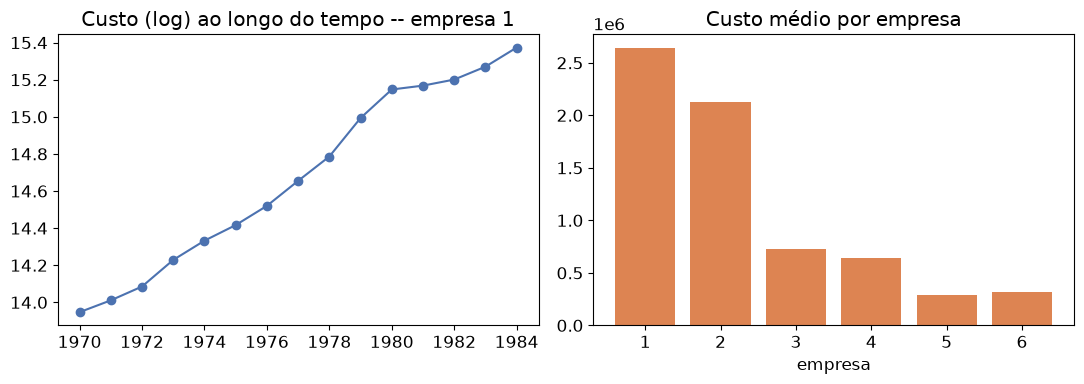

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(df.loc[df['I'] == 1, 'T'], df.loc[df['I'] == 1, 'ln_C'], marker='o', color='#4C72B0')
axes[0].set_title('Custo (log) ao longo do tempo -- empresa 1')

media_por_empresa = df.groupby('I')['C'].mean()
axes[1].bar(media_por_empresa.index, media_por_empresa.values, color='#DD8452')
axes[1].set_title('Custo médio por empresa')
axes[1].set_xlabel('empresa')

plt.tight_layout()
plt.savefig('img_graficos_basicos.png', dpi=110)
plt.show()

## 9. Boas práticas de notebook

Algumas convenções seguidas em todos os notebooks deste curso:
- Uma célula de código por passo lógico (carregar dados, transformar, calcular,
  visualizar) — não misturar tudo em uma célula só.
- Comentar o "porquê", não só o "o quê" (o código já mostra o quê).
- Nomear variáveis em português, de forma descritiva (`retornos`, não `x`).
- Markdown entre células de código para explicar a teoria antes de aplicá-la.
- Rodar o notebook do início ao fim antes de considerar terminado — garante que não há
  células que só funcionam por causa de uma ordem de execução específica.

## 10. Exercícios de fixação

1. Escreva uma função `taxa_efetiva_anual(taxa_mensal)` que retorne a taxa efetiva anual
   equivalente a uma taxa mensal composta (revisitando o
   [módulo de Matemática Financeira](../EXTRA_Matemática_Financeira)).
2. Usando `df` (o dataset de companhias aéreas), calcule o desvio padrão do custo (`C`)
   por empresa com `groupby`.

In [14]:
# 1.
def taxa_efetiva_anual(taxa_mensal):
    return (1 + taxa_mensal) ** 12 - 1

print(f"1) Taxa mensal de 1% -> taxa efetiva anual de {taxa_efetiva_anual(0.01):.2%}")

# 2.
print("\n2) Desvio padrão do custo por empresa:")
print(df.groupby('I')['C'].std().round(2))

1) Taxa mensal de 1% -> taxa efetiva anual de 12.68%

2) Desvio padrão do custo por empresa:
I
1    1241478.08
2    1288108.37
3     342523.03
4     429209.07
5     194263.26
6     295105.06
Name: C, dtype: float64


## Encerramento

Com tipos de dados, estruturas de controle, funções, `numpy`, `pandas` e `matplotlib`
cobertos, a base está pronta para o [Módulo 01 — Estatística Descritiva](../01_Estatística_Descritiva)
— e para o resto da trilha, que assume esses fundamentos como given a partir daqui.

## Bibliografia
- DOWNEY, Allen B. *Think Python*. 2. ed. O'Reilly, 2015.
- McKINNEY, Wes. *Python for Data Analysis*. 3. ed. O'Reilly, 2022.
- VANDERPLAS, Jake. *Python Data Science Handbook*. 2. ed. O'Reilly, 2023.